# Instructions

- This homework assignment is worth 20 points. 
- Please strive for clarity and organization.
- **AI Usage**:
   - AI use is strictly **prohibited** for conceptual exercises.
   - For applied (Python) exercises, you may only use AI for **debugging**. Do not use AI to generate answers.
- **Due Date: November 14, 2025, by 11:59 PM.**

# Exercise 1 (5 points)

Fuzzy matching with Levenshtein: nearest email

```
import Levenshtein

known = [
    "jsmith@quartethealth.com",
    "security@quartethealth.com",
    "talent@quartethealth.com",
    "accommodations-ext@fb.com"
]
```

Given a list of known emails and a misspelled input, return the closest email to `jsmit@quartethalth.com`.

In [1]:
import Levenshtein

known = [
    "jsmith@quartethealth.com",
    "security@quartethealth.com",
    "talent@quartethealth.com",
    "accommodations-ext@fb.com"
]

# return closest email
def get_closest_email(input_email):
    closest_email = None
    smallest_distance = float('inf')

    for email in known:
        distance = Levenshtein.distance(input_email, email)
        if distance < smallest_distance:
            smallest_distance = distance
            closest_email = email

    return closest_email

get_closest_email("jsmit@quartethalth.com")


'jsmith@quartethealth.com'

# Exercise 2 (5 points)

Consider the following text:

```
Apple announced new features on October 13, 2020 in California.
Tim Cook highlighted 5G capabilities. Microsoft and Google also commented.
```

Pass the text to the NLP model. Then, using `displacy` from `spacy`, visualize entities in a more intuitive way.

In [2]:
import spacy
from spacy import displacy

text = "Apple announced new features on October 13, 2020 in California. Tim Cook highlighted 5G capabilities. Microsoft and Google also commented."

nlp = spacy.load("en_core_web_sm")
doc = nlp(text)

# visualize the named entities in the text
displacy.render(doc, style="ent", jupyter=True)

# Exercise 3 (10 points)

Build a word cloud of `long_text` in the shape of a simple binary mask (e.g., a circle). Consider the following function to create the circle:

```
from PIL import Image, ImageDraw

def circular_mask(size=600):
    img = Image.new("L", (size, size), 0)
    draw = ImageDraw.Draw(img)
    draw.ellipse([(0,0),(size-1,size-1)], fill=255)
    return np.array(img)
```

Also, consider the folllowing text for the wordcloud.

```
long_text = '''To Sherlock Holmes she is always _the_
woman. I have seldom heard him mention her under any
other name. In his eyes she eclipses and predominates the
whole of her sex. It was not that he felt any emotion
akin to love for Irene Adler. All emotions, and that
one particularly, were abhorrent to his cold, precise
but admirably balanced mind. He was, I take it, the most
perfect reasoning and observing machine that the world
has seen, but as a lover he would have placed himself in
a false position. He never spoke of the softer passions,
save with a gibe and a sneer. They were admirable things
for the observer—excellent for drawing the veil from
men's motives and actions. But for the trained reasoner
to admit such intrusions into his own delicate and finely
adjusted temperament was to introduce a distracting
factor which might throw a doubt upon all his mental
results. Grit in a sensitive instrument, or a crack in
one of his own high-power lenses, would not be more
disturbing than a strong emotion in a nature such as his.
And yet there was but one woman to him, and that woman
was the late Irene Adler, of dubious and questionable
memory.'''
```

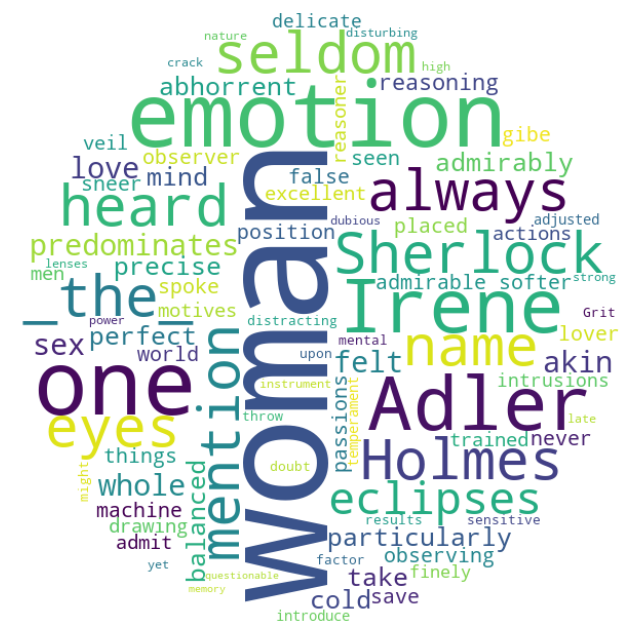

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from wordcloud import WordCloud

def circular_mask(size=600):
    img = Image.new("L", (size, size), 255)
    draw = ImageDraw.Draw(img)
    draw.ellipse([(0,0),(size-1,size-1)], fill=0)
    return np.array(img)

long_text = '''To Sherlock Holmes she is always _the_
woman. I have seldom heard him mention her under any
other name. In his eyes she eclipses and predominates the
whole of her sex. It was not that he felt any emotion
akin to love for Irene Adler. All emotions, and that
one particularly, were abhorrent to his cold, precise
but admirably balanced mind. He was, I take it, the most
perfect reasoning and observing machine that the world
has seen, but as a lover he would have placed himself in
a false position. He never spoke of the softer passions,
save with a gibe and a sneer. They were admirable things
for the observer—excellent for drawing the veil from
men's motives and actions. But for the trained reasoner
to admit such intrusions into his own delicate and finely
adjusted temperament was to introduce a distracting
factor which might throw a doubt upon all his mental
results. Grit in a sensitive instrument, or a crack in
one of his own high-power lenses, would not be more
disturbing than a strong emotion in a nature such as his.
And yet there was but one woman to him, and that woman
was the late Irene Adler, of dubious and questionable
memory.'''

wordcloud = WordCloud(background_color="white", mask=circular_mask()).generate(long_text)
plt.figure(figsize=(8,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()